In [ ]:
import os
import zipfile
import pandas as pd


!pip install -q kaggle
!mkdir -p ~/.kaggle
import json

kaggle_creds = {"username": "birvika","key": "15d2dbff346b377b89dab3f99d4fadd4"}

with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

!chmod 600 ~/.kaggle/kaggle.json

competition_name = "dl-lab-5-metric-learning"
print(f"Скачиваем соревнование {competition_name}")

!kaggle competitions download -c {competition_name} -p /content/ --force


main_zip = "/content/dl-lab-5-metric-learning.zip"
if os.path.exists(main_zip):
    print("Разархивируем основной файл...")
    with zipfile.ZipFile(main_zip, 'r') as zip_ref:
        zip_ref.extractall("/content/")
    os.remove(main_zip)


train_zip = "/content/train.zip"
if os.path.exists(train_zip):
    print("Разархивируем train.zip...")
    with zipfile.ZipFile(train_zip, 'r') as zip_ref:
        zip_ref.extractall("/content/")
    os.remove(train_zip)


test_zip = "/content/test_kaggle.zip"
if os.path.exists(test_zip):
    print("Разархивируем test_kaggle.zip...")
    with zipfile.ZipFile(test_zip, 'r') as zip_ref:
        zip_ref.extractall("/content/")
    os.remove(test_zip)

print("\n" + "="*50)
print("ПРОВЕРКА СТРУКТУРЫ ДАННЫХ")
print("="*50)


base_train_path = "/content/train"
real_train_path = None

if os.path.exists(base_train_path):

    items = os.listdir(base_train_path)
    print(f"\nСодержимое /content/train: {items}")


    if 'train' in items:
        real_train_path = os.path.join(base_train_path, 'train')
        print(f" Найдена вложенная папка: {real_train_path}")
    else:
        real_train_path = base_train_path


if real_train_path and os.path.exists(real_train_path):
    train_folders = [d for d in os.listdir(real_train_path)
                     if os.path.isdir(os.path.join(real_train_path, d))]
    print(f"\n train существует (реальный путь: {real_train_path})")
    print(f"   Количество папок (товаров): {len(train_folders)}")
    print(f"   Примеры папок: {train_folders[:10]}")


    if train_folders:
        first_folder = os.path.join(real_train_path, train_folders[0])
        images = [f for f in os.listdir(first_folder)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"   Фото в папке '{train_folders[0]}': {len(images)}")
else:
    print(" train не найден")
    real_train_path = None


base_test_path = "/content/test_kaggle"
real_test_path = None

if os.path.exists(base_test_path):
    items = os.listdir(base_test_path)
    print(f"\nСодержимое /content/test_kaggle: {items[:20]}")


    if 'test_kaggle' in items:
        real_test_path = os.path.join(base_test_path, 'test_kaggle')
        print(f" Найдена вложенная папка: {real_test_path}")
    else:
        real_test_path = base_test_path

if real_test_path and os.path.exists(real_test_path):
    test_files = [f for f in os.listdir(real_test_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    print(f"\n test_kaggle существует")
    print(f"   Количество изображений: {len(test_files)}")
    print(f"   Примеры: {test_files[:10]}")
else:
    print(" test_kaggle не найден")

submission_path = "/content/submission.csv"
if os.path.exists(submission_path):
    submission = pd.read_csv(submission_path)
    print(f"\nsubmission.csv существует")
    print(f"   Колонки: {submission.columns.tolist()}")
    print(f"   Количество пар: {len(submission)}")
else:
    print("submission.csv не найден")


if real_train_path:
    train_path = real_train_path
else:
    train_path = "/content/train/train"

if real_test_path:
    test_path = real_test_path
else:
    test_path = "/content/test_kaggle/test_kaggle"

%store train_path
%store test_path
%store submission_path

print(f"  train_path = '{train_path}'")
print(f"  test_path = '{test_path}'")
print(f"  submission_path = '{submission_path}'")

Скачиваем соревнование dl-lab-5-metric-learning
100% 382M/382M [00:24<00:00, 16.4MB/s]

Разархивируем основной файл...

ПРОВЕРКА СТРУКТУРЫ ДАННЫХ

Содержимое /content/train: ['train']
 Найдена вложенная папка: /content/train/train

 train существует (реальный путь: /content/train/train)
   Количество папок (товаров): 1000
   Примеры папок: ['44323', '4339703', '3392757', '4291211', '4120696', '39121', '3607262', '4147998', '4282259', '11717']
   Фото в папке '44323': 16

Содержимое /content/test_kaggle: ['test_kaggle']
 Найдена вложенная папка: /content/test_kaggle/test_kaggle

 test_kaggle существует
   Количество изображений: 7761
   Примеры: ['4_D0-CF-13-19-2A-DC_2025-10-12_2025-10-12-22-59-34.jpg', '203_2026-04-15-16-57-03.jpg', '6_2026-01-14-18-59-40.jpg', '15_2025-11-16-11-00-44.jpg', '8_D0-CF-13-23-AD-54_2025-10-05_2025-10-05-01-56-50.jpg', '92_2026-04-14-15-44-27.jpg', '64_2026-01-17-18-55-11.jpg', '29_2026-01-18-19-05-04.jpg', '33_2026-01-19-18-56-54.jpg', '55_D0-CF-13-19-22-3

In [ ]:
import albumentations as A
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn import Parameter
import timm
import os
import random
import math
from collections import Counter
from tqdm import tqdm
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.optim.lr_scheduler import CosineAnnealingLR


SEED = 9999
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = True

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(SEED)


TRAIN_PATH = "/content/train/train"
TEST_PATH = "/content/test_kaggle/test_kaggle"
SUBMISSION_PATH = "/content/submission.csv"
CHECKPOINT_DIR = "/content/lab5_checkpoints"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.cuda.empty_cache()


print("Загрузка классов из train...")
class_folders = [d for d in os.listdir(TRAIN_PATH)
                 if os.path.isdir(os.path.join(TRAIN_PATH, d))]
class_folders.sort()
class_to_idx = {cls: idx for idx, cls in enumerate(class_folders)}
num_classes = len(class_to_idx)

print(f"Всего классов (товаров): {num_classes}")


def letterbox(image, target_size=224, color=(0, 0, 0)):
    h, w = image.shape[:2]
    scale = target_size / max(h, w)
    new_w = int(w * scale)
    new_h = int(h * scale)
    resized = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    padded = np.full((target_size, target_size, 3), color, dtype=np.uint8)
    y_offset = (target_size - new_h) // 2
    x_offset = (target_size - new_w) // 2
    padded[y_offset:y_offset + new_h, x_offset:x_offset + new_w] = resized
    return padded

# ============================================================
#  ADACOS LOSS
# ============================================================
class AdaCos(nn.Module):
    def __init__(self, num_features, num_classes, m=0.40):
        super(AdaCos, self).__init__()
        self.num_features = num_features
        self.n_classes = num_classes
        self.s = math.sqrt(2) * math.log(num_classes - 1)
        self.m = m
        self.W = Parameter(torch.FloatTensor(num_classes, num_features))
        nn.init.xavier_uniform_(self.W)

    def forward(self, input, label=None):
        x = F.normalize(input)
        W = F.normalize(self.W)
        logits = F.linear(x, W)
        if label is None:
            return logits

        theta = torch.acos(torch.clamp(logits, -1.0 + 1e-7, 1.0 - 1e-7))
        one_hot = torch.zeros_like(logits)
        one_hot.scatter_(1, label.view(-1, 1).long(), 1)
        with torch.no_grad():
            B_avg = torch.where(one_hot < 1, torch.exp(self.s * logits), torch.zeros_like(logits))
            B_avg = torch.sum(B_avg) / input.size(0)
            theta_med = torch.median(theta[one_hot == 1])
            self.s = torch.log(B_avg) / torch.cos(torch.min(math.pi/4 * torch.ones_like(theta_med), theta_med))
        output = self.s * logits
        return output

# ============================================================
# ConvNeXt-Tiny
# ============================================================
class MetricModel(nn.Module):
    def __init__(self, backbone_name='convnext_tiny', embedding_size=512, num_classes=None):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=True, num_classes=0)

        if hasattr(self.backbone, 'num_features'):
            in_features = self.backbone.num_features
        else:
            in_features = 768

        self.embedding = nn.Linear(in_features, embedding_size)
        self.bn = nn.BatchNorm1d(embedding_size)
        self.adacos = AdaCos(embedding_size, num_classes, m=0.40) if num_classes else None

    def forward(self, x, labels=None):
        features = self.backbone(x)
        embeddings = self.embedding(features)
        embeddings = self.bn(embeddings)
        embeddings_norm = F.normalize(embeddings, p=2, dim=1)

        if labels is not None and self.adacos is not None:
            logits = self.adacos(embeddings_norm, labels)
            return logits, embeddings_norm
        else:
            return embeddings_norm

# ============================================================
# ДАТАСЕТ
# ============================================================
class ProductDataset(Dataset):
    def __init__(self, images_filepaths, labels, transform=None):
        self.images_filepaths = images_filepaths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.images_filepaths)

    def __getitem__(self, idx):
        image_filepath = self.images_filepaths[idx]

        data = np.fromfile(image_filepath, dtype=np.uint8)
        image = cv2.imdecode(data, cv2.IMREAD_COLOR)
        if image is None:
            image = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = letterbox(image, target_size=224, color=(0, 0, 0))

        if self.transform is not None:
            transformed = self.transform(image=image)
            image = transformed['image']

        return image, self.labels[idx]

# ============================================================
# СБОР ВСЕХ ПУТЕЙ
# ============================================================
print("Сбор путей к изображениям...")
all_paths = []
all_labels = []

for class_name in tqdm(class_folders, desc="Загрузка классов"):
    class_dir = os.path.join(TRAIN_PATH, class_name)
    if not os.path.isdir(class_dir):
        continue

    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_paths.append(os.path.join(class_dir, img_name))
            all_labels.append(class_to_idx[class_name])

print(f"Всего изображений: {len(all_paths)}")


class_counts = Counter(all_labels)
print(f"\nАнализ изображений на класс:")
print(f"   Всего классов: {len(class_counts)}")
print(f"   Изображений на класс: min={min(class_counts.values())}, max={max(class_counts.values())}, mean={np.mean(list(class_counts.values())):.2f}")

# ============================================================
# РАЗБИЕНИЕ
# ============================================================
print("\nРазбиение на train/val (80/20 по ИЗОБРАЖЕНИЯМ)...")

train_paths, val_paths, train_labels, val_labels = train_test_split(
    all_paths, all_labels, test_size=0.2, random_state=SEED, stratify=all_labels
)


unique_labels = sorted(set(train_labels))
label_map = {old: new for new, old in enumerate(unique_labels)}

train_labels_mapped = [label_map[l] for l in train_labels]
val_labels_mapped = [label_map[l] for l in val_labels]

print(f"Train: {len(train_paths)} изображений, {len(unique_labels)} классов")
print(f"Val: {len(val_paths)} изображений, {len(set(val_labels_mapped))} классов")


transform = A.Compose([
    A.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    A.ToTensorV2(),
])


train_dataset = ProductDataset(train_paths, train_labels_mapped, transform=transform)
val_dataset = ProductDataset(val_paths, val_labels_mapped, transform=transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,
    worker_init_fn=seed_worker,
    generator=g
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False,
    worker_init_fn=seed_worker,
    generator=g
)


embedding_size = 512
model = MetricModel(
    backbone_name='convnext_tiny',
    embedding_size=embedding_size,
    num_classes=len(unique_labels)
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=0.01)
scheduler = CosineAnnealingLR(optimizer, T_max=12, eta_min=1e-6)

# ============================================================
# ОБУЧЕНИЕ
# ============================================================
print("\n" + "="*50)
print("НАЧАЛО ОБУЧЕНИЯ (ConvNeXt-Tiny + AdaCos)")
print("embedding_size=512, m=0.40, 12 эпох, ранняя остановка после 3 эпох без улучшений")
print("="*50)

best_loss = float('inf')
patience_counter = 0

for epoch in range(1, 13):
    model.train()
    total_loss = 0.0
    total_samples = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/12")
    for step, (images, labels) in enumerate(pbar):
        images = images.to(device)
        labels = labels.to(device)

        logits, embeddings = model(images, labels)
        loss = F.cross_entropy(logits, labels)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        total_loss += loss.item() * len(images)
        total_samples += len(images)
        avg_loss = total_loss / total_samples

        pbar.set_postfix(loss=f"{avg_loss:.4f}")

    scheduler.step()


    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)
            logits, _ = model(images, labels)
            loss = F.cross_entropy(logits, labels)
            val_loss += loss.item() * len(images)
            val_correct += (logits.argmax(1) == labels).sum().item()
            val_total += len(images)

    val_acc = val_correct / val_total if val_total > 0 else 0
    avg_val_loss = val_loss / val_total if val_total > 0 else 0

    print(f"Epoch {epoch}: Train Loss={avg_loss:.4f}, Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.4f}")


    checkpoint_path = os.path.join(CHECKPOINT_DIR, f'model_epoch_{epoch}.pth')
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
        'val_loss': avg_val_loss,
    }, checkpoint_path)
    print(f"Чекпоинт сохранен: {checkpoint_path}")


    if avg_val_loss < best_loss:
        best_loss = avg_val_loss
        best_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
        torch.save(model.state_dict(), best_path)
        print(f"Сохранена лучшая модель: Val Loss={best_loss:.4f}")
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"Нет улучшения валидационного loss ({patience_counter}/3)")
        if patience_counter >= 3:
            print(f"Ранняя остановка на эпохе {epoch} (нет улучшений 3 эпохи подряд)")
            break

print(f"\nОбучение завершено!")
print(f"Лучший val loss: {best_loss:.4f}")


print("\n" + "="*50)
print("ИНФЕРЕНС")
print("="*50)

best_path = os.path.join(CHECKPOINT_DIR, 'best_model.pth')
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

submission = pd.read_csv(SUBMISSION_PATH)
print(f"Загружено пар: {len(submission)}")

if 'similarity' in submission.columns:
    submission = submission.drop(columns=['similarity'])

all_files = set(submission['file_1'].tolist() + submission['file_2'].tolist())
print(f"Уникальных файлов: {len(all_files)}")

embedding_cache = {}
files_list = list(all_files)

print("Вычисление эмбеддингов...")
for i in tqdm(range(0, len(files_list), 64), desc="Processing"):
    batch_files = files_list[i:i+64]
    batch_images = []
    valid_files = []

    for file_name in batch_files:
        img_path = os.path.join(TEST_PATH, file_name)
        if not os.path.exists(img_path):
            for root, dirs, files in os.walk(TEST_PATH):
                if file_name in files:
                    img_path = os.path.join(root, file_name)
                    break

        image = cv2.imread(img_path)
        if image is None:
            embedding_cache[file_name] = np.zeros(embedding_size, dtype=np.float32)
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = letterbox(image, target_size=224, color=(0, 0, 0))
        image = image.astype(np.float32) / 255.0
        mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
        std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
        image = (image - mean) / std
        tensor = torch.from_numpy(image).permute(2, 0, 1).float()
        batch_images.append(tensor)
        valid_files.append(file_name)

    if batch_images:
        batch_tensor = torch.stack(batch_images).to(device)
        with torch.no_grad():
            embeddings = model(batch_tensor).cpu().numpy()

        for file_name, emb in zip(valid_files, embeddings):
            embedding_cache[file_name] = emb.astype(np.float32)

print("Вычисление similarity...")
similarities = []
for _, row in tqdm(submission.iterrows(), total=len(submission), desc="Pairs"):
    emb1 = embedding_cache.get(row['file_1'], np.zeros(embedding_size, dtype=np.float32))
    emb2 = embedding_cache.get(row['file_2'], np.zeros(embedding_size, dtype=np.float32))
    sim = np.dot(emb1, emb2)
    similarities.append(float(np.clip(sim, 0.0, 1.0)))

submission['similarity'] = similarities
output_path = "predictions_metric.csv"
submission.to_csv(output_path, index=False)

print(f"\nРезультат сохранен в {output_path}")
print(f"Статистика similarity:")
print(f"   Min: {np.min(similarities):.4f}")
print(f"   Max: {np.max(similarities):.4f}")
print(f"   Mean: {np.mean(similarities):.4f}")
print(f"   Std: {np.std(similarities):.4f}")

from google.colab import files
files.download(output_path)
print(f"\nФайл скачан на компьютер")

Device: cuda
GPU: Tesla T4
GPU Memory: 15.6 GB
Загрузка классов из train...
Всего классов (товаров): 1000
Сбор путей к изображениям...


Загрузка классов: 100%|██████████| 1000/1000 [00:00<00:00, 26906.57it/s]

Всего изображений: 13374

Анализ изображений на класс:
   Всего классов: 1000
   Изображений на класс: min=8, max=41, mean=13.37

Разбиение на train/val (80/20 по ИЗОБРАЖЕНИЯМ)...
Train: 10699 изображений, 1000 классов
Val: 2675 изображений, 1000 классов



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

...

Pairs: 100%|██████████| 6262500/6262500 [07:13<00:00, 14430.57it/s]



Результат сохранен в predictions_metric.csv
Статистика similarity:
   Min: 0.0000
   Max: 1.0000
   Mean: 0.0575
   Std: 0.0919


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Файл скачан на компьютер


In [ ]:
import shutil
from google.colab import files

CHECKPOINT_DIR = "/content/lab5_checkpoints"


shutil.make_archive("lab5_checkpoints", 'zip', CHECKPOINT_DIR)

files.download("lab5_checkpoints.zip")



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Загружено 12 чекпоинтов
Эпохи: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Train Loss: [5.68048274 3.13701296 1.31341754 0.81167298 0.74613388 0.71930749
 0.70593401 0.70119625 0.69858314 0.6967065  0.69620884 0.69585674]
Val Loss: [5.57961335 2.593881   1.23150327 0.85764624 0.83058848 0.82572968
 0.81968509 0.81545893 0.81492166 0.81389132 0.81338438 0.81386888]


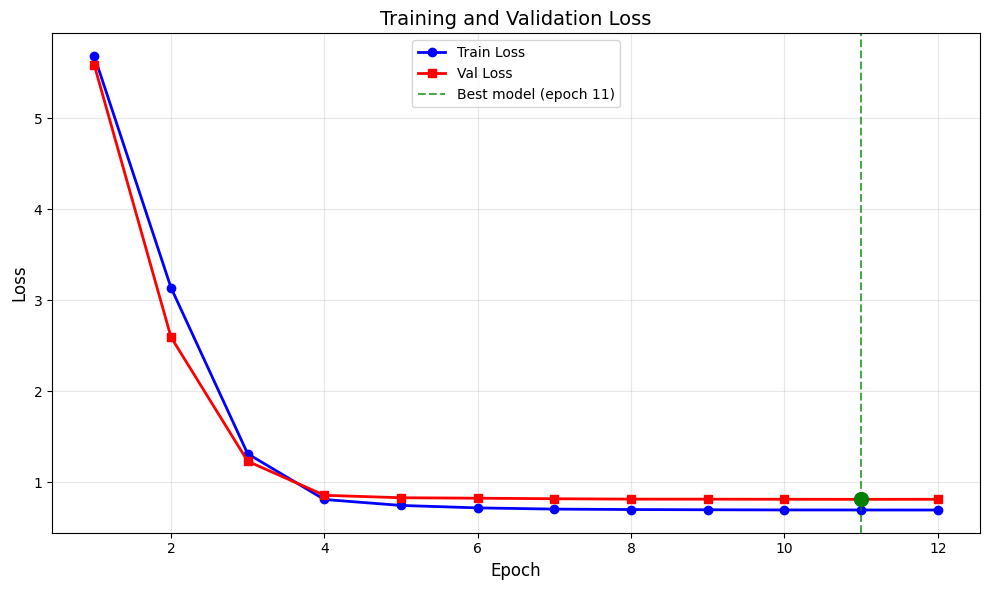


СТАТИСТИКА ОБУЧЕНИЯ

Начало обучения:
  Train Loss: 5.6805
  Val Loss: 5.5796

Лучшая модель (по Val Loss):
  Эпоха: 11
  Train Loss: 0.6962
  Val Loss: 0.8134

Конец обучения:
  Train Loss: 0.6959
  Val Loss: 0.8139

Анализ последних эпох:
  Изменение Train Loss: -0.0004
  Изменение Val Loss: +0.0005
  ВНИМАНИЕ: Начинается переобучение! (Val Loss растет, Train Loss падает)


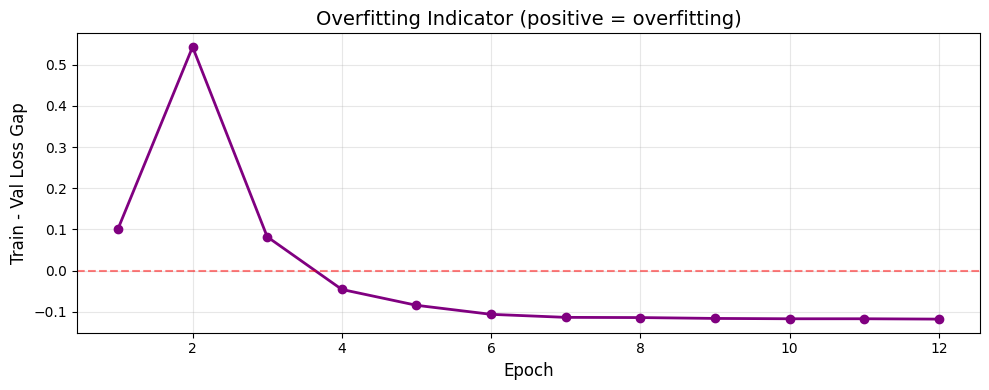


Графики сохранены:
  - training_loss_curves.png
  - overfitting_gap.png


In [ ]:
import os
import torch
import matplotlib.pyplot as plt
import numpy as np


checkpoint_dir = "/content/lab5_checkpoints"


epochs = []
train_losses = []
val_losses = []

for f in sorted(os.listdir(checkpoint_dir)):
    if f.startswith("model_epoch_") and f.endswith(".pth"):
        epoch_num = int(f.split("_")[2].split(".")[0])
        checkpoint_path = os.path.join(checkpoint_dir, f)

        checkpoint = torch.load(checkpoint_path, map_location="cpu")

        epochs.append(epoch_num)
        train_losses.append(checkpoint['loss'])
        val_losses.append(checkpoint['val_loss'])


sorted_indices = np.argsort(epochs)
epochs = np.array(epochs)[sorted_indices]
train_losses = np.array(train_losses)[sorted_indices]
val_losses = np.array(val_losses)[sorted_indices]

print(f"Загружено {len(epochs)} чекпоинтов")
print(f"Эпохи: {epochs}")
print(f"Train Loss: {train_losses}")
print(f"Val Loss: {val_losses}")

fig, ax = plt.subplots(figsize=(10, 6))


ax.plot(epochs, train_losses, 'o-', color='blue', label='Train Loss', linewidth=2, markersize=6)
ax.plot(epochs, val_losses, 's-', color='red', label='Val Loss', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training and Validation Loss', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)


best_idx = np.argmin(val_losses)
best_epoch = epochs[best_idx]
best_val_loss = val_losses[best_idx]
ax.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best model (epoch {best_epoch})')
ax.scatter(best_epoch, best_val_loss, color='green', s=100, zorder=5)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('training_loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()


print("\n" + "="*50)
print("СТАТИСТИКА ОБУЧЕНИЯ")
print("="*50)

print(f"\nНачало обучения:")
print(f"  Train Loss: {train_losses[0]:.4f}")
print(f"  Val Loss: {val_losses[0]:.4f}")

print(f"\nЛучшая модель (по Val Loss):")
print(f"  Эпоха: {best_epoch}")
print(f"  Train Loss: {train_losses[best_idx]:.4f}")
print(f"  Val Loss: {best_val_loss:.4f}")

print(f"\nКонец обучения:")
print(f"  Train Loss: {train_losses[-1]:.4f}")
print(f"  Val Loss: {val_losses[-1]:.4f}")


if len(train_losses) > 1:
    train_diff = train_losses[-1] - train_losses[-2] if len(train_losses) > 1 else 0
    val_diff = val_losses[-1] - val_losses[-2] if len(val_losses) > 1 else 0

    print(f"\nАнализ последних эпох:")
    print(f"  Изменение Train Loss: {train_diff:+.4f}")
    print(f"  Изменение Val Loss: {val_diff:+.4f}")

    if val_diff > 0 and train_diff < 0:
        print("  ВНИМАНИЕ: Начинается переобучение! (Val Loss растет, Train Loss падает)")
    elif val_diff < 0:
        print("  Обучение продолжается, Val Loss снижается")
    else:
        print("  Обучение стабилизировалось")


fig, ax = plt.subplots(figsize=(10, 4))

gap = np.array(train_losses) - np.array(val_losses)
ax.plot(epochs, gap, 'o-', color='purple', linewidth=2, markersize=6)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Train - Val Loss Gap', fontsize=12)
ax.set_title('Overfitting Indicator (positive = overfitting)', fontsize=14)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(True, alpha=0.3)


if len(gap) > 1:
    overfit_started = False
    for i in range(1, len(gap)):
        if gap[i] > 0 and gap[i-1] <= 0:
            ax.axvline(x=epochs[i], color='orange', linestyle='--', alpha=0.7, label=f'Overfitting starts ~ epoch {epochs[i]}')
            ax.legend()
            overfit_started = True
            break
    if not overfit_started and gap[-1] > 0:
        ax.axvline(x=epochs[-1], color='orange', linestyle='--', alpha=0.7, label=f'Overfitting detected at epoch {epochs[-1]}')
        ax.legend()

plt.tight_layout()
plt.savefig('overfitting_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафики сохранены:")
print("  - training_loss_curves.png")
print("  - overfitting_gap.png")